In [2]:
import json
# import plotly.express as px
import pandas as pd
# import openpyxl
import pandas as pd
import matplotlib.pyplot as plt

## Unvaccinated children with starting point

In [1]:
with open('deterministic_horizon_50_year.json') as json_file:
    F_results = json.load(json_file)


In [3]:
# Search for both words in keys
# search_words = ['X', 'Rotavirus', 'Serum_Institute']
# result = {key: value for key, value in F_results.items() if all(word in key for word in search_words)}
# result

# Search for both words in keys, excluding keys with the word "tilda"
search_words = ["X", 'GSK', 'Rotavirus']
result = {key: value for key, value in F_results.items() if all(word in key for word in search_words)}
result

{'X[Rotavirus,GSK,23]': 0.0,
 'X[Rotavirus,GSK,44]': 0.0,
 'X_tilda[Rotavirus,GSK,(37, 41)]': 0.0,
 'X_tilda[Rotavirus,GSK,(32, 36)]': 0.0,
 'X_tilda[Rotavirus,GSK,(16, 20)]': 0.0,
 'X_tilda[Rotavirus,GSK,(10, 14)]': 0.0,
 'X_tilda[Rotavirus,GSK,(40, 40)]': 0.0,
 'X_tilda[Rotavirus,GSK,(15, 19)]': 0.0,
 'X_tilda[Rotavirus,GSK,(5, 5)]': 0.0,
 'X[Rotavirus,GSK,35]': 0.0,
 'X[Rotavirus,GSK,24]': 0.0,
 'X_tilda[Rotavirus,GSK,(26, 28)]': 0.0,
 'X_tilda[Rotavirus,GSK,(18, 22)]': 0.0,
 'X[Rotavirus,GSK,19]': 0.0,
 'X_tilda[Rotavirus,GSK,(42, 44)]': 0.0,
 'X_tilda[Rotavirus,GSK,(4, 4)]': 0.0,
 'X[Rotavirus,GSK,47]': 0.0,
 'X[Rotavirus,GSK,18]': 0.0,
 'X_tilda[Rotavirus,GSK,(22, 22)]': 0.0,
 'X_tilda[Rotavirus,GSK,(12, 16)]': 0.0,
 'X[Rotavirus,GSK,2]': 0.0,
 'X_tilda[Rotavirus,GSK,(34, 34)]': 0.0,
 'X_tilda[Rotavirus,GSK,(35, 37)]': 0.0,
 'X_tilda[Rotavirus,GSK,(12, 14)]': 0.0,
 'X_tilda[Rotavirus,GSK,(14, 14)]': 0.0,
 'X_tilda[Rotavirus,GSK,(29, 33)]': 0.0,
 'X_tilda[Rotavirus,GSK,(3, 3)]': 0

In [4]:
# Search results by keyword for F (tender schedules)
# List of keywords to search for
keywords_to_search = ["S["]

# Initialize a dictionary to store grouped results
grouped_results = {keyword: [] for keyword in keywords_to_search}

# Search for keywords in the JSON keys and group the results
for key, value in F_results.items():
    for keyword in keywords_to_search:
        if keyword in key:
            grouped_results[keyword].append({key: value})


In [5]:

# Extracting data into lists
antigen_list = []
year_list = []
value_list = []

for item in grouped_results['S[']:
    for key, value in item.items():
        # Extracting Antigen and Year from the key
        antigen = key.split(',')[0][2:]
        year = int(key.split(',')[1][:-1])
        
        # Appending values to lists
        antigen_list.append(antigen)
        year_list.append(year)
        value_list.append(value)

# Creating a DataFrame
df = pd.DataFrame({
    'Antigen': antigen_list,
    'Year': year_list,
    'Value': value_list
})

# Displaying the DataFrame
print(df)


         Antigen  Year      Value
0     Diphtheria    15        0.0
1     Diphtheria     6        0.0
2          Mumps    40        0.0
3     Diphtheria    24        0.0
4    Hepatitis_B    29        0.0
..           ...   ...        ...
607          Hib    39        0.0
608        Mumps     1  9977900.0
609    Pertussis    36        0.0
610    Rotavirus    35        0.0
611    Rotavirus     6        0.0

[612 rows x 3 columns]


In [6]:
import pandas as pd

# Assuming df is your DataFrame
# If not, replace df with your DataFrame variable name

# Grouping and counting
result = df.groupby(['Antigen', 'Year'])['Value'].sum().reset_index()
result = result[result['Value'] != 0.0]

# Grouping by Antigen and summing the Value column
# result = df.groupby('Antigen')['Value'].sum().reset_index()

# Displaying the result
print(result)


       Antigen  Year        Value
52         HPV     1   17974979.0
53         HPV     2   19710613.0
54         HPV     3   46510613.0
55         HPV     4  117310613.0
56         HPV     5  208319844.0
256      Mumps     1    9977900.0
307        PCV     1   52119847.0
308        PCV     2    1103625.0
309        PCV     3  202803625.0
409      Polio     1  356386058.0
460  Rotavirus     1  142500000.0


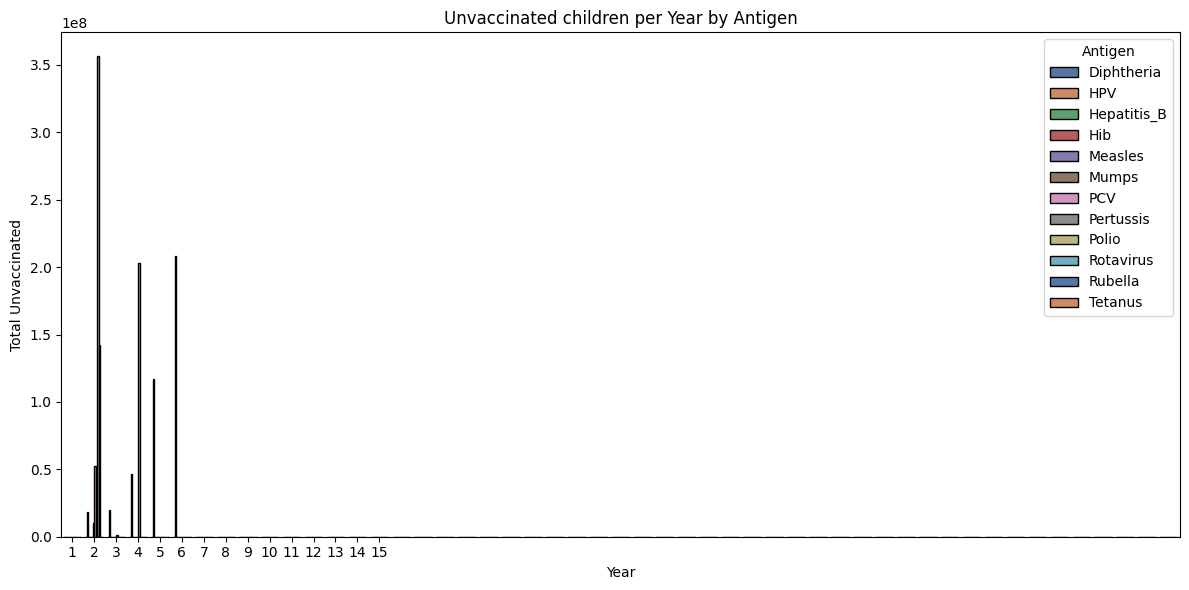

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df is your DataFrame
# If not, replace df with your DataFrame variable name

# Create a list of all years from 1 to 10
all_years = list(range(1, 16))

# Grouping by Year, Antigen, and summing the Value column
result = df.groupby(['Year', 'Antigen'])['Value'].sum().reset_index()

# Filling missing combinations of Year and Antigen with 0.0 value
result = result.pivot_table(index='Year', columns='Antigen', values='Value', fill_value=0.0).reset_index()

# Melt the DataFrame to have a long format suitable for plotting
result = pd.melt(result, id_vars='Year', var_name='Antigen', value_name='Value')

# Set a color palette with distinct colors for each antigen
palette = sns.color_palette("deep", n_colors=len(result['Antigen'].unique()))

# Plotting the bar chart with seaborn
plt.figure(figsize=(12, 6))
sns.barplot(x='Year', y='Value', hue='Antigen', data=result, palette=palette, edgecolor='black')  # Add edgecolor for boxes
plt.xticks(range(len(all_years)), all_years)  # Set x-axis ticks for all years
plt.xlabel('Year')
plt.ylabel('Total Unvaccinated')
plt.title('Unvaccinated children per Year by Antigen')
plt.legend(title='Antigen', bbox_to_anchor=(1, 1))
plt.tight_layout()  # Adjust layout for better visualization
plt.savefig('Deterministic_results_modified_start_unvaccinated_children.png')
plt.show()


In [ ]:
import pandas as pd
import plotly.express as px
import seaborn as sns

# Assuming df is your DataFrame
# If not, replace df with your DataFrame variable name

# Create a list of all years from 1 to 10
all_years = list(range(1, 16))

# Grouping by Year, Antigen, and summing the Value column
result = df.groupby(['Year', 'Antigen'])['Value'].sum().reset_index()

# Filling missing combinations of Year and Antigen with 0.0 value
result = result.pivot_table(index='Year', columns='Antigen', values='Value', fill_value=0.0).reset_index()

# Melt the DataFrame to have a long format suitable for plotting
result = pd.melt(result, id_vars='Year', var_name='Antigen', value_name='Value')

# Set a color palette with distinct colors for each antigen
palette = sns.color_palette("husl", n_colors=len(result['Antigen'].unique()))

# Plotting the bar chart with Plotly Express
fig = px.bar(result, x='Year', y='Value', color='Antigen', barmode='group', text='Value',
             labels={'Value': 'Total Unvaccinated'},
             title='Unvaccinated children per Year by Antigen',
             color_discrete_sequence=palette)

# Add black borders around each bar
fig.update_traces(marker_line_color='black', marker_line_width=1.5)

# Set x-axis ticks for all years
fig.update_xaxes(tickvals=list(range(len(all_years))), ticktext=all_years)

# Customize layout
fig.update_layout(xaxis_title='Year', yaxis_title='Total Unvaccinated', legend_title='Antigen', 
                  legend=dict(title='Antigen', orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1))

# Set a larger plot size
fig.update_layout(width=1000, height=500)

# Show the interactive plot
fig.show()


## Unvaccinated children without starting point

In [ ]:
with open('Deterministic_results.json') as json_file:
    Q_results_clean = json.load(json_file)

In [ ]:
# Search results by keyword for F (tender schedules)
# List of keywords to search for
keywords_to_search = ["S["]

# Initialize a dictionary to store grouped results
grouped_results = {keyword: [] for keyword in keywords_to_search}

# Search for keywords in the JSON keys and group the results
for key, value in Q_results_clean.items():
    for keyword in keywords_to_search:
        if keyword in key:
            grouped_results[keyword].append({key: value})

In [ ]:
grouped_results

In [ ]:

# Extracting data into lists
antigen_list = []
year_list = []
value_list = []

for item in grouped_results['S[']:
    for key, value in item.items():
        # Extracting Antigen and Year from the key
        antigen = key.split(',')[0][2:]
        year = int(key.split(',')[1][:-1])
        
        # Appending values to lists
        antigen_list.append(antigen)
        year_list.append(year)
        value_list.append(value)

# Creating a DataFrame
df = pd.DataFrame({
    'Antigen': antigen_list,
    'Year': year_list,
    'Value': value_list
})

# Displaying the DataFrame
print(df)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df is your DataFrame
# If not, replace df with your DataFrame variable name

# Create a list of all years from 1 to 10
all_years = list(range(1, 11))

# Grouping by Year, Antigen, and summing the Value column
result = df.groupby(['Year', 'Antigen'])['Value'].sum().reset_index()

# Filling missing combinations of Year and Antigen with 0.0 value
result = result.pivot_table(index='Year', columns='Antigen', values='Value', fill_value=0.0).reset_index()

# Melt the DataFrame to have a long format suitable for plotting
result = pd.melt(result, id_vars='Year', var_name='Antigen', value_name='Value')

# Plotting the bar chart with seaborn
plt.figure(figsize=(12, 6))
sns.barplot(x='Year', y='Value', hue='Antigen', data=result)
plt.xticks(range(len(all_years)), all_years)  # Set x-axis ticks for all years
plt.xlabel('Year')
plt.ylabel('Total Unvaccinated')
plt.title('Unvaccinated children per Year by Antigen')
plt.legend(title='Antigen', bbox_to_anchor=(1, 1))
plt.savefig('unvax_childred_without_start.png')
plt.show()
